# Is Traffic Intensity Associated with Road Maintenance Need?
### Evidence from England's Local A-Roads, FYE 2008–2025
**Region:** England &nbsp;&nbsp; **Domain:** Transportation — Road Infrastructure

**Primary question:** Is traffic intensity associated with the proportion of local A-road length that should be considered for maintenance across local authorities in England (FYE 2008–2025)?

This is an association study on observational data; it does not claim causation.


### Key Limitations and Planned Deliverables

The project has several data limitations that require careful treatment.

- Traffic intensity is measured for the whole local road network, while the main outcome covers local A-roads and local-authority-managed motorways. The analysis therefore treats this as a proxy mismatch and avoids causal claims.
- Traffic data use calendar years, while road condition data use financial years, so the project matches them by ending year.
- The same authorities appear in multiple years, so pooled significance is interpreted with caution.
- Administrative changes and missing markers such as `[x]`, `[y]`, and `[z]` are documented and treated as missing values.
- Weather, pavement age, maintenance expenditure, and road composition are unavailable, so some residual variation may reflect unobserved confounding.

## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_val_predict, GridSearchCV)

sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun"]
plt.rcParams["axes.unicode_minus"] = False

TRAFFIC = "local_authority_traffic.csv"
RDC = "rdc0120(1).xlsx"
print("ready")

ready


## 1. Importing Data Sets

**Dataset 1** — [Road traffic estimates in Great Britain (local authority tables TRA8901–8907)](https://www.gov.uk/government/statistics/road-traffic-estimates-in-great-britain-2025), DfT: annual vehicle-miles and road length by local authority, 1993–2025, Great Britain.

**Dataset 2** — [Road conditions in England to March 2025, table RDC0120 (A roads & motorways)](https://www.gov.uk/government/statistics/road-conditions-in-england-to-march-2025), DfT: percentage of local A-road and motorway length where maintenance should have been considered, FYE 2008–2025, England only.

The traffic table is CSV (one row per authority &times; year). The road-condition workbook has title rows above the header, so we use `header=4`, and we select the **A Roads and Motorways** sheet.

In [2]:
df_traffic = pd.read_csv(TRAFFIC)
print("shape:", df_traffic.shape)
df_traffic.head()

shape: (6767, 8)


,local_authority_id,local_authority_name,local_authority_code,year,link_length_km,link_length_miles,cars_and_taxis,all_motor_vehicles
0,1,Isles of Scilly,E06000053,1993,36,22,9.000000e+05,1.400000e+06
1,2,Nottinghamshire,E10000024,1993,4651,2890,2.702600e+09,3.368900e+09
2,3,Glasgow City,S12000049,1993,1769,1099,1.381200e+09,1.662600e+09
3,4,North Lanarkshire,S12000050,1993,1607,999,1.253500e+09,1.547600e+09
4,5,Somerset,E06000066,1993,6630,4120,2.410300e+09,2.958200e+09


In [3]:
df_traffic.describe(include="all")

,local_authority_id,local_authority_name,local_authority_code,year,link_length_km,link_length_miles,cars_and_taxis,all_motor_vehicles
count,6767.000000,6767,6767,6767.000000,6767.000000,6767.000000,6.767000e+03,6.767000e+03
unique,NaN,213,214,NaN,NaN,NaN,NaN,NaN
top,NaN,Redbridge,E08000024,NaN,NaN,NaN,NaN,NaN
freq,NaN,33,33,NaN,NaN,NaN,NaN,NaN
mean,104.175558,NaN,NaN,2009.043742,1916.542042,1190.883996,1.168678e+09,1.482934e+09
std,60.066666,NaN,NaN,9.524639,2244.423969,1394.619698,1.300233e+09,1.657855e+09
min,1.000000,NaN,NaN,1993.000000,34.000000,21.000000,6.000000e+05,1.200000e+06
25%,52.000000,NaN,NaN,2001.000000,563.000000,350.000000,4.310500e+08,5.394000e+08
50%,104.000000,NaN,NaN,2009.000000,978.000000,608.000000,7.072000e+08,8.891000e+08
75%,156.000000,NaN,NaN,2017.000000,2027.000000,1259.500000,1.214050e+09,1.548500e+09


The traffic file covers Great Britain; codes starting with **E** are English authorities. The road-condition file is England-only, so we will keep English rows only.

In [4]:
df_rdc = pd.read_excel(RDC, sheet_name="RDC0120_A_Roads_and_Motorways", header=4)
print("shape:", df_rdc.shape)
df_rdc.head(6)

shape: (160, 22)


,ONS Area Code,Region,Local Authority,FYE 2008,FYE 2009,FYE 2010,FYE 2011,FYE 2012,FYE 2013,FYE 2014,...,FYE 2017,FYE 2018,FYE 2019,FYE 2020,FYE 2021,FYE 2022,FYE 2023,FYE 2024,FYE 2025,Notes
0,E06000047,North East,County Durham UA,5,4,[x],5,6,6,5,...,3,3,3,3,4,4,3,3,3,[z]
1,E06000005,North East,Darlington UA [note 7],6,5,5,6,6,5,3,...,2,1,2,3,2,1,1,7,5,[7] applies to T7 and U7
2,E08000037,North East,Gateshead,4,2,3,6,4,2,2,...,2,1,1,1,1,1,1,1,1,[z]
3,E06000001,North East,Hartlepool UA,1,2,1,2,3,2,5,...,2,2,2,2,3,4,3,3,3,[z]
4,E06000002,North East,Middlesbrough UA,4,1,1,1,3,2,2,...,1,1,2,1,2,1,1,1,1,[z]
5,E08000021,North East,Newcastle upon Tyne [note 7] [r],6,4,3,4,5,5,5,...,3,2,2,2,2,[x],3,6,6,"[7] applies to T11 and U11, [r] applies to T11"


Values contain documented markers: `[x]` unavailable, `[y]` unrepresentative, `[z]` not applicable. The `FYE 2008`–`FYE 2025` columns are yearly percentages (financial year ending).

In [5]:
year_cols = [c for c in df_rdc.columns if str(c).startswith("FYE")]
print("year columns:", len(year_cols))
print("marker counts:",
      "[x]", int((df_rdc[year_cols].astype(str) == "[x]").sum().sum()),
      "[y]", int((df_rdc[year_cols].astype(str) == "[y]").sum().sum()),
      "[z]", int((df_rdc[year_cols].astype(str) == "[z]").sum().sum()))

year columns: 18
marker counts: [x] 113 [y] 14 [z] 148


## 2. Data Wrangling

Steps: (1) decode markers to NaN, (2) transpose the wide year columns to long format, (3) clean authority/region names, (4) keep England traffic, (5) merge on the stable **ONS area code + year**, (6) engineer features, normalize, bin, and create dummy variables.

> **ONS codes** provide a more reliable contemporaneous identifier than authority names. Codes may change when authorities are reorganized, so we match on (code, year) to pair entities only during the periods in which those codes existed. This is more robust than matching on names, which differ in style (e.g. *County Durham* vs *Durham*) and change after boundary reorganizations.

In [6]:
# remove national aggregate row and clean text fields
df_rdc = df_rdc.dropna(subset=["ONS Area Code"])
df_rdc = df_rdc[df_rdc["ONS Area Code"] != "E92000001"]
df_rdc["authority"] = (df_rdc["Local Authority"].astype(str)
                       .str.split("[").str[0].str.strip()
                       .str.replace(" UA", "", regex=False))
df_rdc["region"] = (df_rdc["Region"].astype(str)
                    .str.split("[").str[0].str.strip())

# wide -> long
df_rdc = df_rdc.melt(
    id_vars=["ONS Area Code", "region", "authority"],
    value_vars=year_cols, var_name="fye", value_name="maintenance_pct")
df_rdc["year"] = df_rdc["fye"].str.replace("FYE ", "").astype(int)
df_rdc["maintenance_pct"] = pd.to_numeric(
    df_rdc["maintenance_pct"].replace(["[x]", "[y]", "[z]"], np.nan),
    errors="coerce")
df_rdc = df_rdc.rename(columns={"ONS Area Code": "code"})
print("long shape:", df_rdc.shape,
      "| missing pct:", int(df_rdc["maintenance_pct"].isna().sum()))

long shape: (2862, 6) | missing pct: 275


In [7]:
# England traffic, years in common range
df_tr = df_traffic[
    df_traffic["local_authority_code"].str.startswith("E")
    & df_traffic["year"].between(2008, 2025)].copy()

# inner join on (code, year); drop duplicated key column
df = df_rdc.merge(df_tr, left_on=["code", "year"],
                  right_on=["local_authority_code", "year"], how="inner")
df = df.drop(["local_authority_code", "local_authority_id"], axis=1)
df = df.dropna(subset=["maintenance_pct"]).reset_index(drop=True)
print("merged shape:", df.shape, "| authorities:", df["code"].nunique())

merged shape: (2570, 11) | authorities: 158


Rows without a target are dropped (missing values in the road-condition column). Gaps concentrate in FYE 2011 and FYE 2020–2022, the latter reflecting suspended London SCANNER surveys.

In [8]:
df.rename(columns={"all_motor_vehicles": "total_traffic",
                   "link_length_miles": "road_length_miles"}, inplace=True)

# Traffic intensity = annual vehicle-miles per road-mile (consistent units).
df["traffic_intensity"] = df["total_traffic"] / df["road_length_miles"]

# simple normalization (divide by max), and equal-width binning
df["year_n"] = df["year"] / df["year"].max()
df["intensity_n"] = df["traffic_intensity"] / df["traffic_intensity"].max()

bins = np.linspace(df["traffic_intensity"].min(),
                   df["traffic_intensity"].max(), 4)
df["intensity_group"] = pd.cut(df["traffic_intensity"], bins,
                               labels=["Low", "Medium", "High"],
                               include_lowest=True)

# Region dummies with drop_first=True to avoid the dummy-variable trap
# (the omitted category is the reference group).
region_dummy = pd.get_dummies(df["region"], prefix="region",
                              drop_first=True, dtype=float)
df = pd.concat([df, region_dummy], axis=1)

df.to_csv("england_a_road_clean.csv", index=False)
df[["code", "year", "region", "maintenance_pct",
    "traffic_intensity", "intensity_group"]].head()

,code,year,region,maintenance_pct,traffic_intensity,intensity_group
0,E06000047,2008,North East,5.0,1.063845e+06,Low
1,E06000005,2008,North East,6.0,1.449258e+06,Low
2,E08000037,2008,North East,4.0,1.895707e+06,Medium
3,E06000001,2008,North East,1.0,1.495142e+06,Medium
4,E06000002,2008,North East,4.0,2.234185e+06,Medium


## 3. Exploratory Data Analysis

### 3.1 Descriptive statistics

In [9]:
df[["maintenance_pct", "road_length_miles", "total_traffic",
     "traffic_intensity"]].describe()

,maintenance_pct,road_length_miles,total_traffic,traffic_intensity
count,2570.000000,2570.000000,2.570000e+03,2.570000e+03
mean,4.812451,1270.207004,1.831007e+09,1.745282e+06
std,3.558640,1546.726546,1.948970e+09,5.517451e+05
min,0.000000,29.000000,7.130000e+07,4.640422e+05
25%,2.000000,345.000000,6.171500e+08,1.407448e+06
50%,4.000000,547.000000,1.035250e+09,1.694152e+06
75%,6.000000,1550.500000,2.063500e+09,2.074977e+06
max,35.000000,8139.000000,9.974900e+09,3.493291e+06


### 3.2 Annual trend (unweighted local-authority mean)

The value below is the simple arithmetic mean across available local authorities in each year, **not** a road-length-weighted national average.

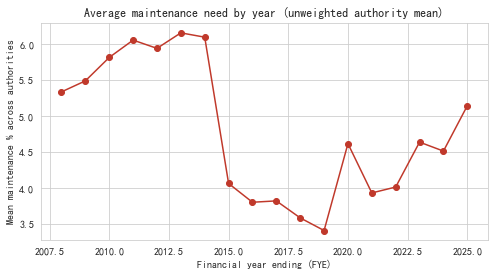

In [10]:
yearly = df.groupby("year", as_index=False)["maintenance_pct"].mean()

plt.figure(figsize=(8, 4))
plt.plot(yearly["year"], yearly["maintenance_pct"], marker="o", color="#c0392b")
plt.xlabel("Financial year ending (FYE)")
plt.ylabel("Mean maintenance % across authorities")
plt.title("Average maintenance need by year (unweighted authority mean)")
plt.show()

### 3.3 Regional comparison

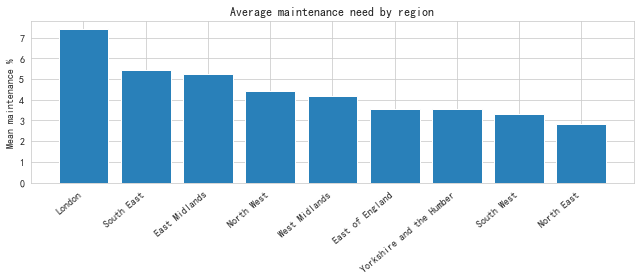

In [11]:
regional = (df.groupby("region", as_index=False)["maintenance_pct"]
              .mean().sort_values("maintenance_pct", ascending=False))

plt.figure(figsize=(9, 4))
plt.bar(regional["region"], regional["maintenance_pct"], color="#2980b9")
plt.xticks(rotation=40, ha="right")
plt.ylabel("Mean maintenance %")
plt.title("Average maintenance need by region")
plt.tight_layout()
plt.show()

### 3.4 Correlation and Pearson test

The pooled Pearson correlation treats every authority-year row as independent. Because the same authority repeats across years (panel data), the p-value should be interpreted cautiously: the weak positive direction is reliable, but conventional significance assumes full independence.

In [12]:
df[["maintenance_pct", "total_traffic", "road_length_miles",
     "traffic_intensity", "year"]].corr()

,maintenance_pct,total_traffic,road_length_miles,traffic_intensity,year
maintenance_pct,1.000000,-0.174606,-0.187679,0.142074,-0.146735
total_traffic,-0.174606,1.000000,0.863407,-0.142176,0.030814
road_length_miles,-0.187679,0.863407,1.000000,-0.452324,0.013459
traffic_intensity,0.142074,-0.142176,-0.452324,1.000000,0.001750
year,-0.146735,0.030814,0.013459,0.001750,1.000000


In [13]:
for c in ["traffic_intensity", "total_traffic",
          "road_length_miles", "year"]:
    r, p = stats.pearsonr(df[c], df["maintenance_pct"])
    p_text = "< 0.001" if p < 0.001 else f"{p:.3f}"
    print(f"{c:18s} r = {r:+.3f}  p = {p_text}")

traffic_intensity  r = +0.142  p = < 0.001
total_traffic      r = -0.175  p = < 0.001
road_length_miles  r = -0.188  p = < 0.001
year               r = -0.147  p = < 0.001


**Sensitivity check:** correlation after averaging each authority over all years (one observation per authority, N ≈ 159), removing repeated-authority dependence.

In [14]:
auth_avg = df.groupby("code", as_index=False).agg(
    {"traffic_intensity": "mean", "maintenance_pct": "mean"})
r, p = stats.pearsonr(auth_avg["traffic_intensity"].astype(float),
                      auth_avg["maintenance_pct"].astype(float))
p_text = "< 0.001" if p < 0.001 else f"{p:.3f}"
print(f"authority-averaged: r = {r:+.3f}  p = {p_text}"
      f"  (N = {len(auth_avg)})")

authority-averaged: r = +0.227  p = 0.004  (N = 158)


### 3.5 Core visualization: maintenance need vs traffic intensity

Each point is one authority-year. The scatter plot and regression line examine the direction, strength and dispersion of the association directly. The slope is shallow relative to the spread, indicating a weak relationship. This is an exploratory view of association, not evidence of causation.

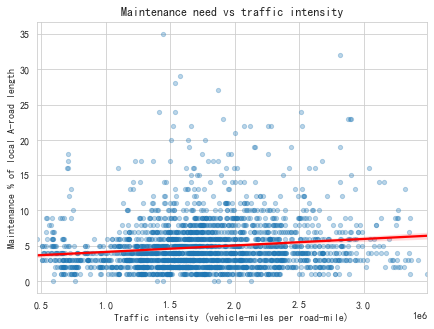

In [15]:
plt.figure(figsize=(7, 5))
sns.regplot(x="traffic_intensity", y="maintenance_pct", data=df,
            scatter_kws={"alpha": 0.3, "s": 18},
            line_kws={"color": "red"})
plt.xlabel("Traffic intensity (vehicle-miles per road-mile)")
plt.ylabel("Maintenance % of local A-road length")
plt.title("Maintenance need vs traffic intensity")
plt.show()

### 3.6 Box plots: intensity groups and regions

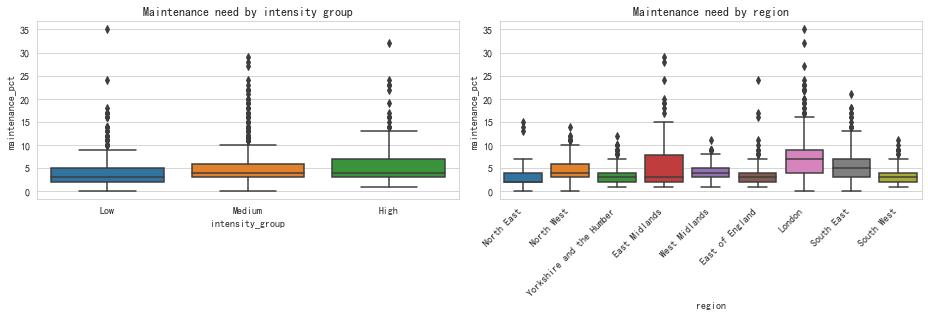

intensity_group
Low       4.08
Medium    5.02
High      5.68
Name: maintenance_pct, dtype: float64

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x="intensity_group", y="maintenance_pct", data=df,
            order=["Low", "Medium", "High"], ax=axes[0])
axes[0].set_title("Maintenance need by intensity group")
sns.boxplot(x="region", y="maintenance_pct", data=df, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_title("Maintenance need by region")
plt.tight_layout()
plt.show()

df.groupby("intensity_group")["maintenance_pct"].mean().round(2)

### 3.7 Heat map: region x year

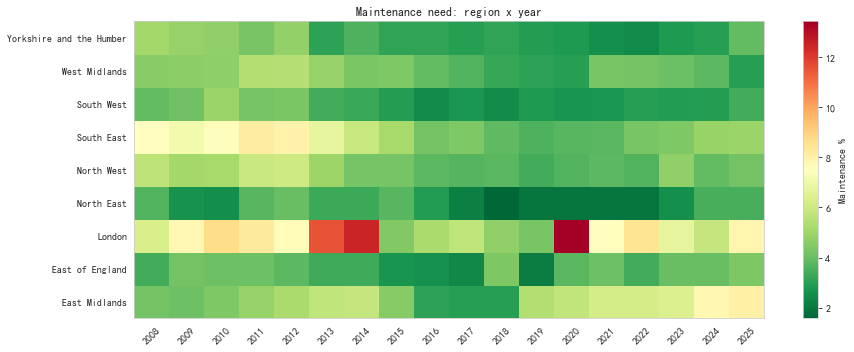

In [17]:
pv = (df.groupby(["region", "year"])["maintenance_pct"]
        .mean().unstack())
plt.figure(figsize=(13, 5))
plt.pcolor(pv, cmap="RdYlGn_r")
plt.colorbar(label="Maintenance %")
plt.yticks(np.arange(0.5, len(pv.index), 1), pv.index)
plt.xticks(np.arange(0.5, len(pv.columns), 1), pv.columns, rotation=45)
plt.title("Maintenance need: region x year")
plt.tight_layout()
plt.show()

### 3.8 EDA findings
- Maintenance need varies by year and region (London highest, North East lowest) with no strong one-directional long-run trend.
- Traffic intensity has a **weak but positive** association with maintenance percentage (r &asymp; 0.14); authority-level averaging preserves the direction.
- Region differences are clear, so region indicators are useful in modelling.

## 4. Model Development

**Target:** `maintenance_pct`. **Features:** `year_n`, `intensity_n`, and region dummies (with one reference region omitted to avoid perfect multicollinearity). We avoid putting `total_traffic`, `cars_and_taxis`, `cars_share` and `road_length` together because they are nearly perfectly correlated (e.g. cars &asymp; 0.999 &times; total traffic).

In [18]:
region_cols = [c for c in df.columns if c.startswith("region_")]
y = df["maintenance_pct"].astype(float)
X = df[["year_n", "intensity_n"] + region_cols].astype(float)
x_int = df[["intensity_n"]].astype(float)
print("X shape:", X.shape)

X shape: (2570, 10)


### 4.1 Simple linear regression (intensity only)

In [19]:
lr = LinearRegression()
lr.fit(x_int, y)
print("intercept:", round(lr.intercept_, 3),
      "| coef:", np.round(lr.coef_, 3))
print("in-sample R2:", round(r2_score(y, lr.predict(x_int)), 4))

intercept: 3.213 | coef: [3.201]
in-sample R2: 0.0202


### 4.2 Multiple linear regression (year + intensity + regions)

In [20]:
mlr = LinearRegression()
mlr.fit(X, y)
yhat = mlr.predict(X)
print("intercept:", round(mlr.intercept_, 3))
print("in-sample R2:", round(r2_score(y, yhat), 4),
      "| MSE:", round(mean_squared_error(y, yhat), 4))

intercept: 187.388
in-sample R2: 0.2033 | MSE: 10.086


### 4.3 Polynomial regression (degree 3, intensity)

In [21]:
x = df["intensity_n"].values
f = np.polyfit(x, y.values, 3)
p = np.poly1d(f)
print("in-sample R2:", round(r2_score(y, p(x)), 4))

in-sample R2: 0.0225


### 4.4 Polynomial pipeline (degree 2)

In [22]:
pipe = Pipeline([("scale", StandardScaler()),
                  ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                  ("model", LinearRegression())])
Z = df[["year_n", "intensity_n"]].astype(float)
pipe.fit(Z, y)
print("in-sample R2:", round(r2_score(y, pipe.predict(Z)), 4))

in-sample R2: 0.0543


### 4.5 Diagnostic plots

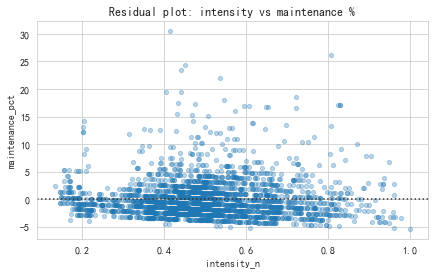

In [23]:
plt.figure(figsize=(7, 4))
sns.residplot(x=df["intensity_n"], y=df["maintenance_pct"],
              scatter_kws={"alpha": 0.3, "s": 18})
plt.title("Residual plot: intensity vs maintenance %")
plt.show()

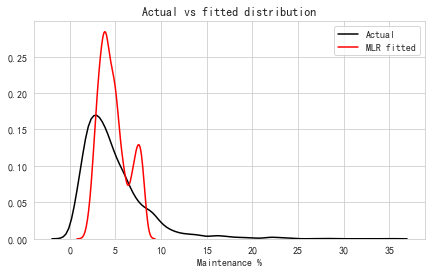

In [24]:
plt.figure(figsize=(7, 4))
sns.kdeplot(y, label="Actual", color="black")
sns.kdeplot(mlr.predict(X), label="MLR fitted", color="red")
plt.xlabel("Maintenance %")
plt.title("Actual vs fitted distribution")
plt.legend()
plt.show()

## 5. Model Evaluation and Refinement

We compare models on a held-out test set. To check the panel-data concern (same authority in both train and test), we add a **temporal holdout** (train on &le;2021, test on &ge;2022) as a stricter sensitivity test.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (2056, 10) | test: (514, 10)


In [26]:
results = []

# 1. simple linear
lr.fit(X_train[["intensity_n"]], y_train)
r1 = lr.predict(X_test[["intensity_n"]])
results.append(("SLR intensity", r2_score(y_test, r1),
                mean_squared_error(y_test, r1)))

# 2. multiple linear
mlr.fit(X_train, y_train)
r2 = mlr.predict(X_test)
results.append(("MLR year+intensity+regions", r2_score(y_test, r2),
                mean_squared_error(y_test, r2)))

# 3. polynomial degree 3
f_tr = np.polyfit(X_train["intensity_n"].values, y_train.values, 3)
p_tr = np.poly1d(f_tr)
r3 = p_tr(X_test["intensity_n"].values)
results.append(("Poly-3 intensity", r2_score(y_test, r3),
                mean_squared_error(y_test, r3)))

# 4. polynomial pipeline
Z_train, Z_test, _, _ = train_test_split(
    Z, y, test_size=0.20, random_state=1)
pipe.fit(Z_train, y_train)
r4 = pipe.predict(Z_test)
results.append(("Pipeline poly-2", r2_score(y_test, r4),
                mean_squared_error(y_test, r4)))

res = pd.DataFrame(results, columns=["model", "R2", "MSE"])
res.round(4)

,model,R2,MSE
0,SLR intensity,-0.0027,13.3303
1,MLR year+intensity+regions,0.1719,11.0088
2,Poly-3 intensity,0.0001,13.2939
3,Pipeline poly-2,0.0025,13.2615


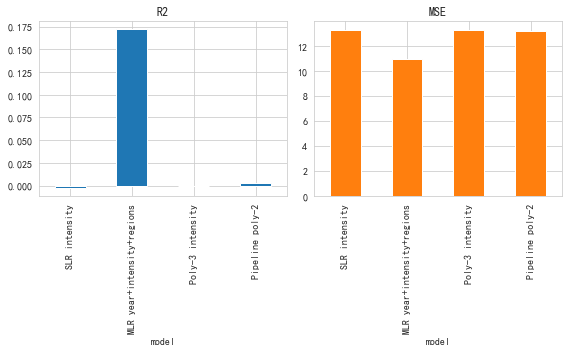

In [27]:
res.set_index("model")[["R2", "MSE"]].plot(kind="bar", subplots=True,
    figsize=(8, 5), layout=(1, 2), legend=False)
plt.tight_layout()
plt.show()

### 5.1 Cross-validation

In [28]:
Rc = cross_val_score(LinearRegression(), X, y, cv=4)
print("fold R2:", np.round(Rc, 3))
print("mean R2:", round(Rc.mean(), 4), "| std:", round(Rc.std(), 4))
yhat_cv = cross_val_predict(LinearRegression(), X, y, cv=4)
print("out-of-fold R2:", round(r2_score(y, yhat_cv), 4),
      "| MSE:", round(mean_squared_error(y, yhat_cv), 4))

fold R2: [ 0.122  0.222  0.02  -0.067]
mean R2: 0.074 | std: 0.1085
out-of-fold R2: 0.122 | MSE: 11.1143


Cross-validation shows limited and somewhat unstable out-of-sample performance across folds.

### 5.2 Ridge with grid search

In [29]:
pr = PolynomialFeatures(degree=2)
Xtr_pr = pr.fit_transform(Z_train)
Xte_pr = pr.fit_transform(Z_test)

grid = GridSearchCV(Ridge(), {"alpha": [0.001, 0.1, 1, 10, 100, 1000]}, cv=4)
grid.fit(Xtr_pr, y_train)
best = grid.best_estimator_
yhat_ridge = best.predict(Xte_pr)
print("best alpha:", grid.best_params_["alpha"])
print("test R2:", round(r2_score(y_test, yhat_ridge), 4),
      "| MSE:", round(mean_squared_error(y_test, yhat_ridge), 4))

best alpha: 0.001
test R2: 0.0082 | MSE: 13.1851


The best alpha is very close to 0, so Ridge regularization does not materially improve performance. This suggests that large polynomial coefficients (overfitting) are not the main limitation; rather, the selected traffic variables carry limited predictive information about maintenance percentage.

### 5.3 Sensitivity test: temporal holdout

Train on FYE 2008–2021, test on FYE 2022–2025. This avoids the same authority appearing in both sets via a different year, and mirrors the realistic task of predicting future maintenance need from past data.

In [30]:
train_idx = df["year"] <= 2021
Xtr, Xte = X[train_idx], X[~train_idx]
ytr, yte = y[train_idx], y[~train_idx]

mlr.fit(Xtr, ytr)
pred = mlr.predict(Xte)
print("temporal holdout R2:", round(r2_score(yte, pred), 4),
      "| MSE:", round(mean_squared_error(yte, pred), 4),
      f"| train years {int(df.loc[train_idx,'year'].min())}–"
      f"{int(df.loc[train_idx,'year'].max())},"
      f" test years {int(df.loc[~train_idx,'year'].min())}–"
      f"{int(df.loc[~train_idx,'year'].max())}")

temporal holdout R2: -0.0325 | MSE: 13.0915 | train years 2008–2021, test years 2022–2025


### 5.4 Conclusions
1. **Trend & geography:** the unweighted mean maintenance percentage fluctuates between roughly 3.4% and 6.2% across FYE 2008–2025, with clear regional differences (London highest, North East lowest).
2. **Association:** traffic intensity has a weak positive association with maintenance need (pooled r &asymp; 0.14; the direction holds after authority-level averaging). Longer road networks show a weak negative association, but the mechanism is unclear and may reflect road composition, geography or measurement rather than a mechanical dilution effect.
3. **Modelling:** the multiple linear regression (year + intensity + regions) is the best-performing model on held-out data, clearly beating traffic-only models. Polynomial terms and Ridge do not help. Traffic intensity alone has almost no predictive power; year and region carry most of the signal.

**Limitations:** road-class mismatch (whole-network traffic vs A-road-only outcome), temporal mismatch between FYE and calendar year, repeated authority-year observations (panel structure) that weaken standard independence assumptions, and missing covariates (weather, pavement age, maintenance spending).